In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

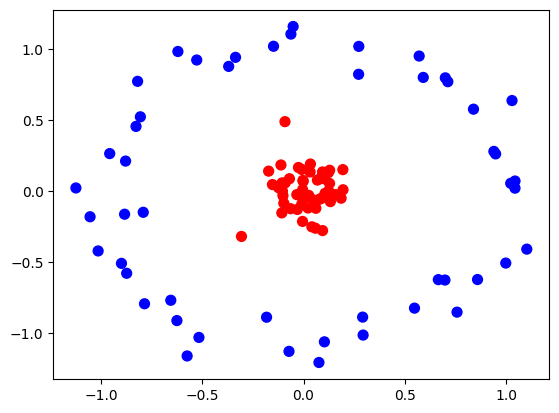

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [6]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.3

In [8]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_149344/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


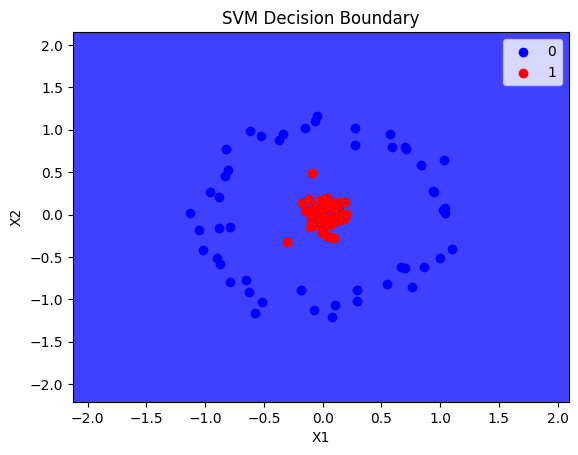

In [9]:
plot_decision_boundary(X, y, classifier)

In [10]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

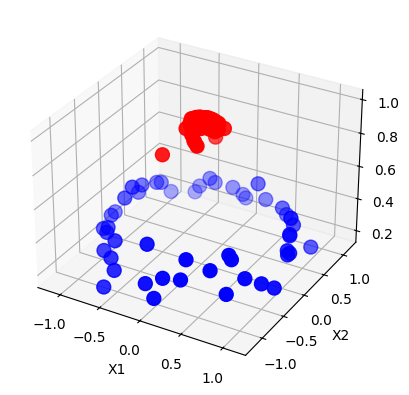

In [11]:
plot_3d_plot(X,y)

In [12]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [13]:

accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_149344/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


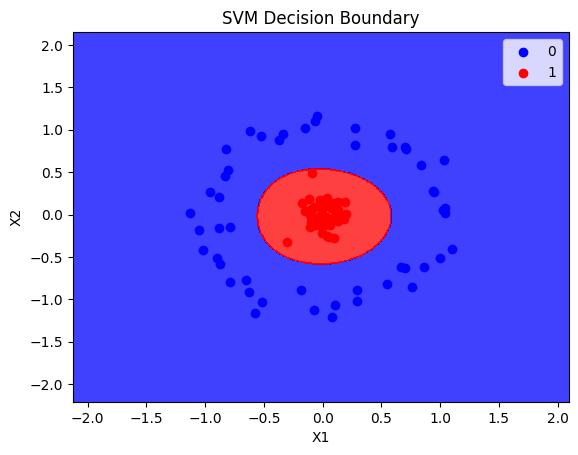

In [14]:
plot_decision_boundary(X, y, rbf_classifier)

In [15]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_149344/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


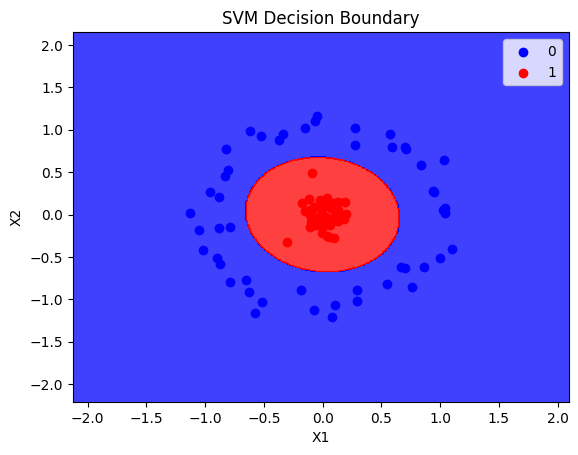

In [17]:
plot_decision_boundary(X, y, poly_classifier)

In [18]:
X

array([[ 6.66022991e-01, -6.23766481e-01],
       [ 1.02363847e+00,  5.54203841e-02],
       [ 2.73200980e-01,  1.02133537e+00],
       [ 1.85700439e-01, -4.94710322e-02],
       [ 3.25847011e-02,  1.35519320e-01],
       [-3.06478262e-01, -3.19141759e-01],
       [-1.56652680e-03,  6.98963578e-02],
       [-6.22791942e-02,  1.10796160e+00],
       [ 2.59743048e-02, -2.98835477e-02],
       [-5.16595145e-01, -1.03146854e+00],
       [-8.99303512e-01, -5.09203755e-01],
       [-7.91745791e-01, -1.48872523e-01],
       [-5.74853907e-01, -1.16217175e+00],
       [-1.53350187e-01,  4.67482601e-02],
       [ 1.04474549e+00,  7.16508907e-02],
       [-6.20539636e-01,  9.85232996e-01],
       [ 8.39671593e-01,  5.78413585e-01],
       [ 1.94343521e-01,  1.52015126e-01],
       [-9.15194375e-03,  1.53562590e-01],
       [ 6.25767416e-02, -6.68535488e-02],
       [-1.72317293e-01,  1.41391252e-01],
       [-1.01457847e+00, -4.21475261e-01],
       [ 5.48227495e-01, -8.25047394e-01],
       [ 5.

In [19]:
np.exp(-(X**2)).sum(1)

array([1.31940756, 1.34762922, 1.2804302 , 1.96365878, 1.98074093,
       1.81351116, 1.99512396, 1.28912992, 1.99843294, 1.11087003,
       1.21701632, 1.51234679, 0.97766883, 1.97457506, 1.33059416,
       1.0592272 , 1.20973594, 1.94009132, 1.97661065, 1.99163238,
       1.95095028, 1.19447475, 1.24666924, 1.23004148, 1.25671244,
       1.96192593, 1.4318867 , 1.98416823, 1.9969061 , 1.071902  ,
       1.97711271, 1.98060294, 1.04558274, 1.22649619, 1.98073651,
       1.99066343, 1.93719619, 1.9306275 , 1.27385236, 1.33732067,
       1.30342829, 1.97458611, 1.97179819, 1.28896736, 1.12463272,
       1.98964791, 1.9998721 , 1.99832055, 1.99391184, 1.98340767,
       1.98874634, 1.98852993, 1.14235862, 1.1819467 , 1.43534422,
       1.95549767, 1.31589785, 1.28179193, 1.33954936, 1.98748015,
       1.98918567, 1.95405482, 1.91690908, 1.98166708, 1.99419898,
       1.97290193, 1.27399754, 1.98840023, 1.15237522, 1.42091021,
       1.98921363, 1.96811236, 1.31273076, 1.33315993, 1.05946

In [20]:
X_new=np.exp(-(X**2))

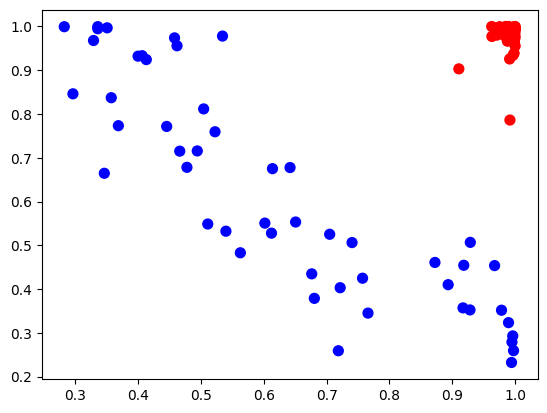

In [21]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')